In [119]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import math
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn import datasets
from sklearn.metrics import mean_squared_error, r2_score    
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve, ShuffleSplit, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay, classification_report, f1_score, roc_auc_score,accuracy_score,recall_score,precision_score
from sklearn.preprocessing import StandardScaler,minmax_scale
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier 


In [120]:
dataset = pd.read_csv("D:\\ISE_LAB\\ML-Newbie-Training\\Week 3\\NB\\Practice 2\\kc_house_data.csv")  
pd.set_option('display.max_columns',None)
pd.set_option('display.max_row',None)
print(dataset.head())
dt=pd.to_datetime(dataset['date'],format='%Y%m%dT%H%M%S')
dataset['year']=dt.dt.year
dataset['month']=dt.dt.month
dataset['day']=dt.dt.day
data=dataset.drop('date',axis=1)

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000 221900.00         3       1.00         1180   
1  6414100192  20141209T000000 538000.00         3       2.25         2570   
2  5631500400  20150225T000000 180000.00         2       1.00          770   
3  2487200875  20141209T000000 604000.00         4       3.00         1960   
4  1954400510  20150218T000000 510000.00         3       2.00         1680   

   sqft_lot  floors  waterfront  view  condition  grade  sqft_above  \
0      5650    1.00           0     0          3      7        1180   
1      7242    2.00           0     0          3      7        2170   
2     10000    1.00           0     0          3      6         770   
3      5000    1.00           0     0          5      7        1050   
4      8080    1.00           0     0          3      8        1680   

   sqft_basement  yr_built  yr_renovated  zipcode   lat    long  \
0              0      1955           

In [121]:
print(data.head())

           id     price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0  7129300520 221900.00         3       1.00         1180      5650    1.00   
1  6414100192 538000.00         3       2.25         2570      7242    2.00   
2  5631500400 180000.00         2       1.00          770     10000    1.00   
3  2487200875 604000.00         4       3.00         1960      5000    1.00   
4  1954400510 510000.00         3       2.00         1680      8080    1.00   

   waterfront  view  condition  grade  sqft_above  sqft_basement  yr_built  \
0           0     0          3      7        1180              0      1955   
1           0     0          3      7        2170            400      1951   
2           0     0          3      6         770              0      1933   
3           0     0          5      7        1050            910      1965   
4           0     0          3      8        1680              0      1987   

   yr_renovated  zipcode   lat    long  sqft_living15  s

In [122]:
print(dataset['date'].nunique())

372


In [123]:
print(dataset.info())

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [124]:

print(dataset.describe())


                 id      price  bedrooms  bathrooms  sqft_living   sqft_lot  \
count      21613.00   21613.00  21613.00   21613.00     21613.00   21613.00   
mean  4580301520.86  540088.14      3.37       2.11      2079.90   15106.97   
std   2876565571.31  367127.20      0.93       0.77       918.44   41420.51   
min      1000102.00   75000.00      0.00       0.00       290.00     520.00   
25%   2123049194.00  321950.00      3.00       1.75      1427.00    5040.00   
50%   3904930410.00  450000.00      3.00       2.25      1910.00    7618.00   
75%   7308900445.00  645000.00      4.00       2.50      2550.00   10688.00   
max   9900000190.00 7700000.00     33.00       8.00     13540.00 1651359.00   

        floors  waterfront     view  condition    grade  sqft_above  \
count 21613.00    21613.00 21613.00   21613.00 21613.00    21613.00   
mean      1.49        0.01     0.23       3.41     7.66     1788.39   
std       0.54        0.09     0.77       0.65     1.18      828.09   
min 

In [ ]:
scaler=StandardScaler()
y=data['price']/1000
X=data.drop(['id','price'],axis=1)
print(X.shape)
print(y.shape)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)


(21613, 21)
(21613,)
(17290, 21) (4323, 21)
(17290,) (4323,)
            0        1        2        3        4        5        6        7   \
count 17290.00 17290.00 17290.00 17290.00 17290.00 17290.00 17290.00 17290.00   
mean     -0.00    -0.00    -0.00    -0.00     0.00     0.00    -0.00     0.00   
std       1.00     1.00     1.00     1.00     1.00     1.00     1.00     1.00   
min      -3.62    -2.76    -1.97    -0.37    -0.92    -0.08    -0.31    -3.69   
25%      -0.40    -0.80    -0.71    -0.25    -0.92    -0.08    -0.31    -0.63   
50%      -0.40     0.18    -0.18    -0.19     0.00    -0.08    -0.31    -0.63   
75%       0.68     0.50     0.51    -0.11     0.92    -0.08    -0.31     0.91   
max      31.82     7.68    11.00    29.61     3.69    11.77     4.95     2.44   

            8        9        10       11       12       13       14       15  \
count 17290.00 17290.00 17290.00 17290.00 17290.00 17290.00 17290.00 17290.00   
mean     -0.00    -0.00    -0.00    -0.00     0

In [126]:
#LinearRegression
import math
mod_ln=LinearRegression()
mod_ln.fit(X_train,y_train)
train_pred=mod_ln.predict(X_train)
test_pred=mod_ln.predict(X_test)
train_r2=f"{r2_score(y_train,train_pred):0.2f}"
train_mse=mean_squared_error(y_train,train_pred)
print("train : " , train_r2 ,f"{math.sqrt(train_mse):0.0f}")
test_r2=f"{r2_score(y_test,test_pred):0.2f}"
test_mse=mean_squared_error(y_test,test_pred)
print("test : " , test_r2 , f"{math.sqrt(test_mse):0.0f}")

train :  0.70 198
test :  0.70 212


In [127]:
from sklearn.linear_model import LassoCV
mod_ls_cv = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5, max_iter=10000, n_jobs=-1)
mod_ls_cv.fit(X_train, y_train)
print(f"Alpha tốt nhất: {mod_ls_cv.alpha_}")

train_pred=mod_ls_cv.predict(X_train)
test_pred=mod_ls_cv.predict(X_test)
train_r2=f"{r2_score(y_train,train_pred):0.2f}"
train_mse=mean_squared_error(y_train,train_pred)
print("train : " , train_r2 ,f"{math.sqrt(train_mse):0.0f}")
test_r2=f"{r2_score(y_test,test_pred):0.2f}"
test_mse=mean_squared_error(y_test,test_pred)
print("test : " , test_r2 , f"{math.sqrt(test_mse):0.0f}")

Alpha tốt nhất: 0.26560877829466867
train :  0.70 198
test :  0.70 212


In [128]:
from sklearn.linear_model import RidgeCV
mod_rg_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
mod_rg_cv.fit(X_train, y_train)
print(f"Alpha tốt nhất: {mod_rg_cv.alpha_}")

train_pred=mod_rg_cv.predict(X_train)
test_pred=mod_rg_cv.predict(X_test)
train_r2=f"{r2_score(y_train,train_pred):0.2f}"
train_mse=mean_squared_error(y_train,train_pred)
print("train : " , train_r2 ,f"{math.sqrt(train_mse):0.0f}")
test_r2=f"{r2_score(y_test,test_pred):0.2f}"
test_mse=mean_squared_error(y_test,test_pred)
print("test : " , test_r2 , f"{math.sqrt(test_mse):0.0f}")

Alpha tốt nhất: 141.74741629268047
train :  0.70 198
test :  0.70 212


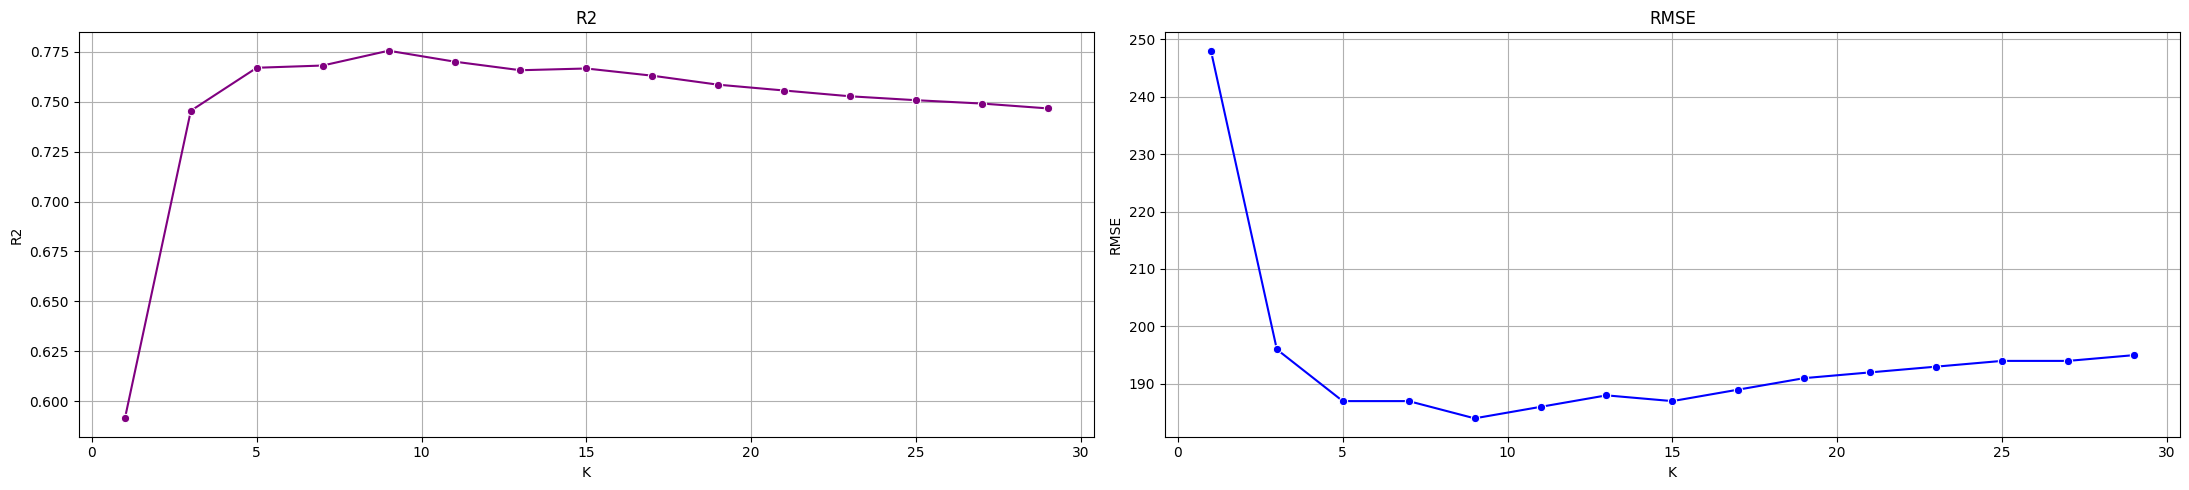

   K   R2  RMSE
4  9 0.78   184


In [129]:
r2_=[]
rmse_=[]
x_train=X_train
x_test=X_test
for i in range(1,31,2):
    model=KNeighborsRegressor(n_neighbors=i,metric='minkowski',p=2,weights='distance')
    model.fit(x_train,y_train)
    y_pred= model.predict(x_test)

  
    r2=r2_score(y_test,y_pred)
    rmse=math.sqrt(mean_squared_error(y_test,y_pred))
    r2_.append(r2)
    rmse_.append(int(rmse))
results = pd.DataFrame({
    'K': list(range(1, 31, 2)),
    'R2': r2_,
    'RMSE': rmse_,
})
fig, axes = plt.subplots(1, 2, figsize=(22, 5))
sns.lineplot(data=results, x='K', y='R2', ax=axes[0], marker='o', color='purple')
axes[0].grid()
axes[0].set_title('R2')

sns.lineplot(data=results, x='K', y='RMSE', ax=axes[1], marker='o', color='blue')
axes[1].grid()
axes[1].set_title('RMSE')

plt.tight_layout()
plt.show()
print(results[results['RMSE'] == results['RMSE'].min()])


In [130]:
#LASSO
mod_rr=RandomForestRegressor()
param_grid = {
    'max_depth': [3, 11, 15, 24], 
    'min_samples_leaf': [1, 5, 7, 9, 15],
    'max_features':  [4, 6, 10, 16],
    'n_estimators': [5,10,20,30]
}
classifier = GridSearchCV(estimator=mod_rr, param_grid=param_grid,
                            n_jobs=-1, scoring='r2')
classifier.fit(X_train, y_train)

print('Best_score (R2):',math.sqrt(classifier.best_score_ ))
print(classifier.best_estimator_)

Best_score (R2): 0.9356203720199505
RandomForestRegressor(max_depth=24, max_features=16, n_estimators=30)


In [131]:

mod_rg_cv = RandomForestRegressor(max_depth=50,max_features=10,n_estimators=75)
mod_rg_cv.fit(X_train, y_train)

train_pred=mod_rg_cv.predict(X_train)
test_pred=mod_rg_cv.predict(X_test)
train_r2=f"{r2_score(y_train,train_pred):0.2f}"
train_mse=mean_squared_error(y_train,train_pred)
print("train : " , train_r2 ,f"{math.sqrt(train_mse):0.0f}")
test_r2=f"{r2_score(y_test,test_pred):0.2f}"
test_mse=mean_squared_error(y_test,test_pred)
print("test : " , test_r2 , f"{math.sqrt(test_mse):0.0f}")

train :  0.98 48
test :  0.86 147
